# 04 Predicting from Data with Machine Learning in Python

<center><img src="figs/02_regression.png" alt="Drawing" width=450px/></center>
<center>Want to know if a house/car/bicycle/computer is a good deal?</center>
    
   <center> Linear regression can help.</center>


# Outline of ECE 3: Recap 

- 01: Welcome to Python
- 02: Computing with Data in Python
- 03: Summarizing and Visualizing Data in Python
- **04: Predicting from Data with Machine Learning in Python**
  - **What is Machine Learning? How it is different from AI?**
  - **Clustering**
  - Linear regression

# Outline of Unit 04: Today's lecture

- **04: Predicting from Data with Machine Learning in Python**
  - What is Machine Learning? How it is different from AI?
  - Clustering
  - **Linear regression**
    - **Functions and Linear Functions**
    - **Regression and Linear Regression**

# Functions and Linear Functions

### Math Definition: Function $f:\mathbb{R}^n \rightarrow \mathbb{R}$

$\color{#EF5645}{\text{Definition}}$: A _function_ $f$ from the $n$-vectors to the scalars is a rule that assigns to each $n$-vector exactly one scalar.
- We denote $f:\mathbb{R}^n \rightarrow \mathbb{R}$ such a function. 
- $\mathbb{R}^n$ is the _input space, or domain_, of $f$.
- $\mathbb{R}$ is its _output space, or codomain_, of $f$.

$\color{#047C91}{\text{Exercise}}$: 
- Give an example of function going from $\mathbb{R}^3$ to $\mathbb{R}$.


### Graph of a function $f:\mathbb{R}^n \rightarrow \mathbb{R}$

When $n=1$ or $n=2$, the function $f: \mathbb{R}^n \rightarrow \mathbb{R}$ can be visually represented by a graph.

$\color{#047C91}{\text{Exercise}}$: Give input/output spaces of the functions below.

<center><img src="figs/02_affine_only.png" width=250px alt="default"/></center>

<center><img src="figs/02_graph.png" width=250px alt="default"/></center>

### Linear Function $f:\mathbb{R}^n \rightarrow \mathbb{R}$

$\color{#EF5645}{\text{Definition}}$: A function $f: \mathbb{R}^n \rightarrow \mathbb{R}$ is called _linear_, if it write $f(x) = a^T.x$ for some $n$-vector of parameters $a$.

$\color{#047C91}{\text{Example}}$: The function $f: \mathbb{R}^2 \rightarrow \mathbb{R}$ defined by:
$$f(x_1, x_2) = x_1 + 2 x_2,$$
for all possible 2-vectors $x = (x_1, x_2)$ is linear.

### Affine function $f:\mathbb{R}^n \rightarrow \mathbb{R}$ 

$\color{#EF5645}{\text{Definition}}$: A function $f:\mathbb{R}^n \rightarrow \mathbb{R}$ that is linear plus a constant is called _affine_. Its general form is:

$$f(x) = a^Tx+b \quad \text{with $a$ an $n$-vector and $b$ a scalar}$$


$\color{#047C91}{\text{Example}}$: The function $f:\mathbb{R}^4 \rightarrow \mathbb{R}$ defined as $f(x_1, x_2, x_3, x_4) = x_2 + 5$ is affine.

### Linear versus affine functions

In this plot, $f$ is linear and $g$ is affine, not linear
<center><img src="figs/02_linear_vs_affine.jpg" alt="Drawing" width=750px/></center>
😱 Sometimes people refer to affine functions as linear. 

For example: in linear regression!

# Regression and Linear Regression

### Regression

$\color{#EF5645}{\text{Definition}}$: A _regression_ is an algorithm that predicts a continuous _output_, $y$, based on the value of one or more _inputs_, collectively denoted $x$.
- A regression learns a function $f:\mathbb{R}^n \rightarrow \mathbb{R}$, that assigns $y$ to a given $n$-vector of inputs $x$.

$\color{#047C91}{\text{Example}}$: You want to predict the price of a house $y$, given its area and number of bedrooms, collectively denoted $x$.

### Machine Learning

How to find the "magic" function $f$ that makes predictions?
- Teach machine to learn it from data:  _machine learning_.

First, we assume that $f$ is already learned and is given to us.

Next, we will see how to learn $f$.

### Linear Regression Model

We believe that a scalar $y$ and an $n$-vector $x$ are related by the model $$y_{\text{true}} ≈ f_{\text{true}}(x) = a_{\text{true}}^T.x+b_{\text{true}}$$ 

Generally, we do not know $f_{\text{true}}$, we just assume it exists. Our goal is to learn $f_{\text{true}}$, or a reasonable approximation of it, using data.

$\color{#EF5645}{\text{Definition}}$: A _linear regression model_ will learn an affine function:
$$y_{\text{pred}} = f(x) = a^T.x + b$$
where:
- the $n$-vector $x$ is called _input vector_,
- the $n$-vector $a$ is called _weight vector_ that estimates $a_{\text{true}}$,
- the scalar $b$ is called _intercept_ or _bias_, that estimates $b_{\text{true}}$,
- the scalar $y_{\text{pred}}$ is called _prediction_ of the true _outcome_ $y_{\text{true}}$.

### Example: House prices

- Outcome $y$: price of house in \$1000.
- Regressors $x$: (area, # bedrooms), area in 1000 sq.ft.

We are given a regression model with weight vector and offset as:

$a= (148.73, −18.85), b= 54.40$

$\color{#047C91}{\text{Exercise}}$: From this trained regression model, what is the predicted price of a house with 2000 sq.ft and 3 bedrooms?

$\color{#003660}{\text{In Python}}$, we check how our model compares to real data. 

We import the package `pandas` to load data from a `.csv`, using its function `read_csv`.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv("../data/02_houses.csv"); data

,Unnamed: 0,baths,location,price,beds,area,condo
0,0,2,2,94.905,2,0.941,1
1,1,2,2,98.937,3,1.146,0
2,2,2,2,100.309,3,0.909,0
3,3,2,3,106.250,3,1.289,0
4,4,1,3,107.502,3,1.020,0
...,...,...,...,...,...,...,...
769,769,3,3,232.425,4,2.280,0
770,770,2,3,234.000,3,1.477,0
771,771,2,2,235.000,3,1.216,0
772,772,2,3,235.301,4,1.685,0


In [12]:
a = np.array([148.73, -18.85])
b = 54.40

real_price = data["price"]
x_area = data["area"]
x_beds = data["beds"]

x = np.array([x_area, x_beds]).T
print(x.shape)

def y_hat(x):
    return np.inner(a, x) + b
    
predicted_price = y_hat(x)
print(predicted_price.shape)

(774, 2)
(774,)


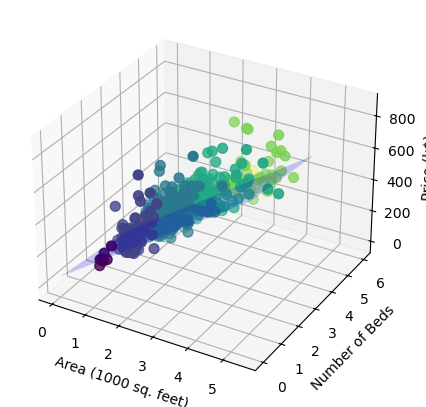

In [13]:
# No need to understand the following code.
fg = plt.figure(figsize=(5, 5)); ax = fg.add_subplot(projection='3d')
ax.scatter(x_area, x_beds, real_price, c=x_beds, s=50); ax.set_xlabel("Area (1000 sq. feet)", fontsize=10); ax.set_ylabel("Number of Beds", fontsize=10); ax.set_zlabel("Price (k$)", fontsize=10);

x_beds_grid = np.arange(0, 6, 0.5); x_area_grid = np.arange(0, 4, 0.5)
X, Y = np.meshgrid(x_beds_grid, x_area_grid)
zs = np.array(y_hat(np.array([np.ravel(X), np.ravel(Y)]).T)); Z = zs.reshape(X.shape)
ax.plot_surface(X, Y, Z, alpha=0.2, color="blue"); plt.show();

# How do we find this approximate linear function?

### We find the parameters (a, b) that minimize the prediction error (Residual)

Consider that we have $N$ samples.

Our predictions are ${y^{(i)}}_{\text{pred}} = f(x_i)$, for $i=1, ..., N$. 

If our model is good, then $y_{\text{pred}}^{(i)} ≈ y^{(i)}$ for $i=1, ..., N$.


$\color{#EF5645}{\text{Definition}}$: We define the _prediction error_, or _residual_, for each sample $i=1, ..., N$: 
$$r_i = y^{(i)} - y_{\text{pred}}^{(i)}.$$

### Least Square Data Fitting

We find the parameters of the linear function by least squares.

$\color{#EF5645}{\text{Definition}}$: The Least Square Data Fitting problem is the problem of choosing model's parameters $a, b$ that minimize the _loss_:
$$\text{Loss}(a, b) = \frac{r_1^2 + ... + r_N^2}{N}.$$


$\color{#003660}{\text{In Python}}$, we use the `minimize` function from the package `scipy`.

In [18]:
from scipy.optimize import minimize

y = real_price
X = np.column_stack([np.ones(len(x_area)), x_area, x_beds])
#print(X[:10])

# w = [b, a1, a2]
def loss(w):
    preds = X @ w  # aT. x + b. 1 = a1 x1 + a2 x2 + b*1 =  b*1 + a1 x1 + a2 x2 
    return np.mean((preds - y)**2)

# Minimize
w0 = np.zeros(3)
res = minimize(loss, w0)
w_opt = res.x

# Predict
y_pred = X @ w_opt

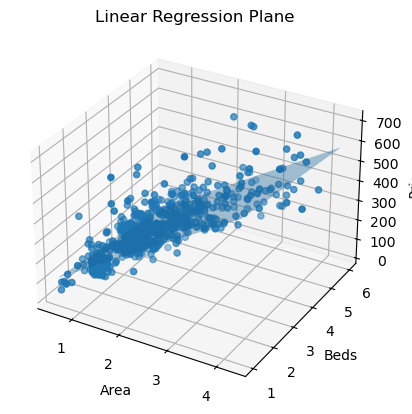

array([ 54.40164161, 148.72503765, -18.85333132])

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_area, x_beds, y, label="Data")

# Create plane
area_grid, beds_grid = np.meshgrid(
    np.linspace(x_area.min(), x_area.max(), 20),
    np.linspace(x_beds.min(), x_beds.max(), 20)
)
price_plane = w_opt[0] + w_opt[1]*area_grid + w_opt[2]*beds_grid

ax.plot_surface(area_grid, beds_grid, price_plane, alpha=0.4)

ax.set_xlabel("Area")
ax.set_ylabel("Beds")
ax.set_zlabel("Price")
plt.title("Linear Regression Plane")

plt.show()

w_opt

<center><img src="figs/02_regression.png" alt="Drawing" width=850px/></center>

<center>Want to know if a house/car/bicycle/computer is a good deal? Linear functions can help.</center>


# Outline of ECE 3

- 01: Welcome to Python
- 02: Computing with Data in Python
- 03: Summarizing and Visualizing Data in Python
- 04: Predicting from Data with Machine Learning in Python

Congratulations !

<center><img src="figs/00_signal_processing.jpeg" width=1000px alt="default"/></center>